# Stock Movement Classification from Financial News — v4

Predicts 3-class stock movement (UP / NEUTRAL / DOWN) from financial news using TF-IDF, ticker, mentions, and sentiment features. Compares against sentiment-only and FinBERT baselines to quantify the value of the full pipeline.

**Key design decisions:**
- ±2% neutral band to focus on extremes
- Cached hyperparameters (load on rerun, skip grid search)
- Sentiment-only baseline and FinBERT baseline for comparison
- Feature names reconstructed from TF-IDF vocabularies
- Confusion matrix and per-class metrics


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_and_clean_data

RANDOM_STATE = 42
NEUTRAL_BAND = 0.02  # ±2% neutral zone
TRAIN_FRAC = 0.70
CV_FOLDS = 5
CACHE_FILE = 'hyperparameters.json'

SENTIMENT_COLS = ['raw_sentiment_negative', 'raw_sentiment_neutral', 'raw_sentiment_positive']
EMOTION_COLS = [
    'raw_emotion_neutral', 'raw_emotion_surprise', 'raw_emotion_disgust',
    'raw_emotion_anger', 'raw_emotion_sadness', 'raw_emotion_joy', 'raw_emotion_fear',
]

sns.set_style('whitegrid')
print('✓ Setup complete')

✓ Setup complete


## 1. Load Data & Create Target

In [2]:
df = load_and_clean_data('data')
df['date_publish'] = pd.to_datetime(df['date_publish'])
df = df.sort_values('date_publish').reset_index(drop=True)
df = df[df['prev_price'] > 0].reset_index(drop=True)
df['return'] = (df['next_price'] - df['prev_price']) / df['prev_price']

def label_return(ret, band):
    labels = pd.Series('NEUTRAL', index=ret.index, dtype=object)
    labels[ret > band] = 'UP'
    labels[ret < -band] = 'DOWN'
    return labels

df['target'] = label_return(df['return'], NEUTRAL_BAND)

print(f'Samples: {len(df):,}')
print(f'Date range: {df["date_publish"].min().date()} → {df["date_publish"].max().date()}')
print(f'\nTarget distribution:')
print(df['target'].value_counts().sort_index())
print(f'\n{df["target"].value_counts(normalize=True).round(3).to_string()}')

Samples: 85,957
Date range: 2017-01-04 → 2023-12-27

Target distribution:
target
DOWN       17627
NEUTRAL    50707
UP         17623
Name: count, dtype: int64

target
NEUTRAL    0.590
DOWN       0.205
UP         0.205


## 2. Train / Test Split (Temporal)

In [3]:
n_train = int(len(df) * TRAIN_FRAC)
df_train = df.iloc[:n_train].copy()
df_test = df.iloc[n_train:].copy()

y_train = df_train['target'].values
y_test = df_test['target'].values

print(f'Train: {len(df_train):,} ({df_train["date_publish"].min().date()} → {df_train["date_publish"].max().date()})')
print(f'Test:  {len(df_test):,} ({df_test["date_publish"].min().date()} → {df_test["date_publish"].max().date()})')

Train: 60,169 (2017-01-04 → 2023-02-06)
Test:  25,788 (2023-02-06 → 2023-12-27)


## 3. Build Features

In [4]:
# TF-IDF: Title
vec_title = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True, strip_accents='unicode')
X_title_train = vec_title.fit_transform(df_train['title'].fillna(''))
X_title_test = vec_title.transform(df_test['title'].fillna(''))

# TF-IDF: Body
vec_text = TfidfVectorizer(ngram_range=(1,1), min_df=20, max_df=0.5, stop_words='english', sublinear_tf=True, strip_accents='unicode')
X_text_train = vec_text.fit_transform(df_train['maintext'].fillna(''))
X_text_test = vec_text.transform(df_test['maintext'].fillna(''))

# Ticker: One-Hot
try:
    enc_ticker = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    enc_ticker = OneHotEncoder(handle_unknown='ignore', sparse=True)
X_ticker_train = enc_ticker.fit_transform(df_train[['ticker']])
X_ticker_test = enc_ticker.transform(df_test[['ticker']])

# Mentions: Multi-hot
def coerce_list(s):
    return s.apply(lambda x: x if isinstance(x, list) else [])
mlb_mentions = MultiLabelBinarizer(sparse_output=True)
X_mentions_train = mlb_mentions.fit_transform(coerce_list(df_train['mentioned_companies']))
X_mentions_test = mlb_mentions.transform(coerce_list(df_test['mentioned_companies']))

# Sentiment & Emotion: Dense
X_sentiment_train = df_train[SENTIMENT_COLS + EMOTION_COLS].values.astype(np.float32)
X_sentiment_test = df_test[SENTIMENT_COLS + EMOTION_COLS].values.astype(np.float32)

print('Title:      ', X_title_train.shape)
print('Text:       ', X_text_train.shape)
print('Ticker:     ', X_ticker_train.shape)
print('Mentions:   ', X_mentions_train.shape)
print('Sentiment:  ', X_sentiment_train.shape)

Title:       (60169, 67732)
Text:        (60169, 36824)
Ticker:      (60169, 49)
Mentions:    (60169, 49)
Sentiment:   (60169, 10)


## 4. Normalize Sparse Features

In [5]:
def L2_norm(X_tr, X_te):
    norm = Normalizer(norm='l2')
    return norm.fit_transform(X_tr), norm.transform(X_te)

X_title_train, X_title_test = L2_norm(X_title_train, X_title_test)
X_text_train, X_text_test = L2_norm(X_text_train, X_text_test)
X_ticker_train, X_ticker_test = L2_norm(X_ticker_train, X_ticker_test)
X_mentions_train, X_mentions_test = L2_norm(X_mentions_train, X_mentions_test)

# Keep sentiment as-is (already normalized probabilities)
X_sentiment_train = sp.csr_matrix(X_sentiment_train)
X_sentiment_test = sp.csr_matrix(X_sentiment_test)

print('✓ Normalization complete')

✓ Normalization complete


## 5. Baseline 1: Sentiment-Only Model

In [6]:
# Sentiment features only
X_sentiment_only_train = X_sentiment_train
X_sentiment_only_test = X_sentiment_test

# Tune C on 5-fold CV
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
param_grid = {'C': [0.1, 0.3, 1.0, 3.0, 10.0]}
clf_sentiment = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', 
                                   random_state=RANDOM_STATE, n_jobs=-1)
gs_sentiment = GridSearchCV(clf_sentiment, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
gs_sentiment.fit(X_sentiment_only_train, y_train)

best_C_sentiment = gs_sentiment.best_params_['C']
y_pred_sentiment = gs_sentiment.predict(X_sentiment_only_test)
f1_sentiment = f1_score(y_test, y_pred_sentiment, average='macro')
acc_sentiment = accuracy_score(y_test, y_pred_sentiment)

print(f'Sentiment-Only Baseline')
print(f'  Best C: {best_C_sentiment}')
print(f'  Test Macro-F1: {f1_sentiment:.4f}')
print(f'  Test Accuracy: {acc_sentiment:.4f}')

Sentiment-Only Baseline
  Best C: 0.3
  Test Macro-F1: 0.3293
  Test Accuracy: 0.3875


## 6. Baseline 2: FinBERT Embeddings

In [ ]:
try:
    from transformers import AutoTokenizer, BertForSequenceClassification
    import torch
    
    print('Loading FinBERT...')
    model_name = 'ProsusAI/finbert'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    # Load as the correct architecture (classification model), then use its base BERT
    # for embeddings — avoids unexpected-key warnings from loading a classifier
    # checkpoint into a plain BertModel
    finbert = BertForSequenceClassification.from_pretrained(model_name)
    model = finbert.bert
    model.eval()
    
    def get_finbert_embeddings(texts, batch_size=32):
        """Extract [CLS] token embeddings from FinBERT."""
        embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=512)
            with torch.no_grad():
                outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # [batch, 768]
            embeddings.append(cls_embeddings)
        return np.vstack(embeddings)
    
    # Convert to Python lists (tokenizer does not accept NumPy arrays)
    texts_train = (df_train['title'] + ' ' + df_train['maintext']).fillna('').tolist()
    texts_test = (df_test['title'] + ' ' + df_test['maintext']).fillna('').tolist()
    
    print('Computing FinBERT embeddings (train)...')
    X_finbert_train = get_finbert_embeddings(texts_train)
    print(f'  Shape: {X_finbert_train.shape}')
    
    print('Computing FinBERT embeddings (test)...')
    X_finbert_test = get_finbert_embeddings(texts_test)
    print(f'  Shape: {X_finbert_test.shape}')
    
    # Tune FinBERT classifier
    clf_finbert = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga',
                                     random_state=RANDOM_STATE, n_jobs=-1)
    gs_finbert = GridSearchCV(clf_finbert, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
    gs_finbert.fit(X_finbert_train, y_train)
    
    best_C_finbert = gs_finbert.best_params_['C']
    y_pred_finbert = gs_finbert.predict(X_finbert_test)
    f1_finbert = f1_score(y_test, y_pred_finbert, average='macro')
    acc_finbert = accuracy_score(y_test, y_pred_finbert)
    
    print(f'\nFinBERT Baseline')
    print(f'  Best C: {best_C_finbert}')
    print(f'  Test Macro-F1: {f1_finbert:.4f}')
    print(f'  Test Accuracy: {acc_finbert:.4f}')
    
    finbert_available = True
except Exception as e:
    print(f'⚠ FinBERT not available: {e}')
    finbert_available = False

## 7. Main Model: Full Pipeline

In [8]:
# Concatenate all features
X_train_full = sp.hstack([
    X_ticker_train, X_title_train, X_text_train, X_mentions_train, X_sentiment_train
], format='csr')
X_test_full = sp.hstack([
    X_ticker_test, X_title_test, X_text_test, X_mentions_test, X_sentiment_test
], format='csr')

print(f'Full feature matrix: train={X_train_full.shape}, test={X_test_full.shape}')

# Check if cached hyperparameters exist
if Path(CACHE_FILE).exists():
    with open(CACHE_FILE) as f:
        cached_hp = json.load(f)
    best_C_main = cached_hp.get('main_C', 1.0)
    print(f'\nLoading cached hyperparameters: best_C = {best_C_main}')
else:
    print(f'\nGrid searching for best C...')
    clf_main = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga',
                                  random_state=RANDOM_STATE, n_jobs=-1)
    gs_main = GridSearchCV(clf_main, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
    gs_main.fit(X_train_full, y_train)
    best_C_main = gs_main.best_params_['C']
    print(f'Best C found: {best_C_main}')
    
    # Cache it
    with open(CACHE_FILE, 'w') as f:
        json.dump({'main_C': best_C_main}, f)
    print(f'✓ Cached to {CACHE_FILE}')

# Train final model
clf_final = LogisticRegression(C=best_C_main, max_iter=1000, class_weight='balanced', 
                               solver='saga', random_state=RANDOM_STATE, n_jobs=-1)
clf_final.fit(X_train_full, y_train)
y_pred_main = clf_final.predict(X_test_full)
y_pred_proba = clf_final.predict_proba(X_test_full)

f1_main = f1_score(y_test, y_pred_main, average='macro')
acc_main = accuracy_score(y_test, y_pred_main)
prec_main = precision_score(y_test, y_pred_main, average='macro')
rec_main = recall_score(y_test, y_pred_main, average='macro')

print(f'\nMain Model (Full Pipeline)')
print(f'  Features: Ticker + Title + Body + Mentions + Sentiment')
print(f'  Best C: {best_C_main}')
print(f'  Test Macro-F1: {f1_main:.4f}')
print(f'  Test Accuracy: {acc_main:.4f}')
print(f'  Test Precision: {prec_main:.4f}')
print(f'  Test Recall: {rec_main:.4f}')

Full feature matrix: train=(60169, 104664), test=(25788, 104664)

Grid searching for best C...
Best C found: 1.0
✓ Cached to hyperparameters.json

Main Model (Full Pipeline)
  Features: Ticker + Title + Body + Mentions + Sentiment
  Best C: 1.0
  Test Macro-F1: 0.3681
  Test Accuracy: 0.4425
  Test Precision: 0.3766
  Test Recall: 0.3806


## 8. Comparison: Model vs Baselines

In [9]:
comparison = {
    'Model': ['Majority Baseline', 'Sentiment-Only', 'Main Pipeline'],
    'Macro-F1': [
        f1_score(y_test, [y_test[0]] * len(y_test), average='macro'),
        f1_sentiment,
        f1_main
    ],
    'Accuracy': [
        accuracy_score(y_test, [y_test[0]] * len(y_test)),
        acc_sentiment,
        acc_main
    ],
    'Precision': [
        0,
        precision_score(y_test, y_pred_sentiment, average='macro'),
        prec_main
    ],
    'Recall': [
        0,
        recall_score(y_test, y_pred_sentiment, average='macro'),
        rec_main
    ]
}

if finbert_available:
    comparison['Model'].insert(2, 'FinBERT')
    comparison['Macro-F1'].insert(2, f1_finbert)
    comparison['Accuracy'].insert(2, acc_finbert)
    comparison['Precision'].insert(2, precision_score(y_test, y_pred_finbert, average='macro'))
    comparison['Recall'].insert(2, recall_score(y_test, y_pred_finbert, average='macro'))

df_comparison = pd.DataFrame(comparison).round(4)
print('\n' + '='*70)
print('MODEL COMPARISON')
print('='*70)
print(df_comparison.to_string(index=False))

# Improvement over sentiment baseline
improvement = (f1_main - f1_sentiment) / f1_sentiment * 100
print(f'\nImprovement over Sentiment-Only: +{improvement:.1f}%')


MODEL COMPARISON
            Model  Macro-F1  Accuracy  Precision  Recall
Majority Baseline    0.0994    0.1753     0.0000  0.0000
   Sentiment-Only    0.3293    0.3875     0.3418  0.3444
    Main Pipeline    0.3681    0.4425     0.3766  0.3806

Improvement over Sentiment-Only: +11.8%


## 9. Per-Class Metrics

In [10]:
print('Main Pipeline: Per-Class Performance')
print(classification_report(y_test, y_pred_main, digits=4))

Main Pipeline: Per-Class Performance
              precision    recall  f1-score   support

        DOWN     0.2125    0.2825    0.2425      4521
     NEUTRAL     0.6968    0.5171    0.5937     16336
          UP     0.2204    0.3421    0.2681      4931

    accuracy                         0.4425     25788
   macro avg     0.3766    0.3806    0.3681     25788
weighted avg     0.5208    0.4425    0.4699     25788



## 10. Confusion Matrix

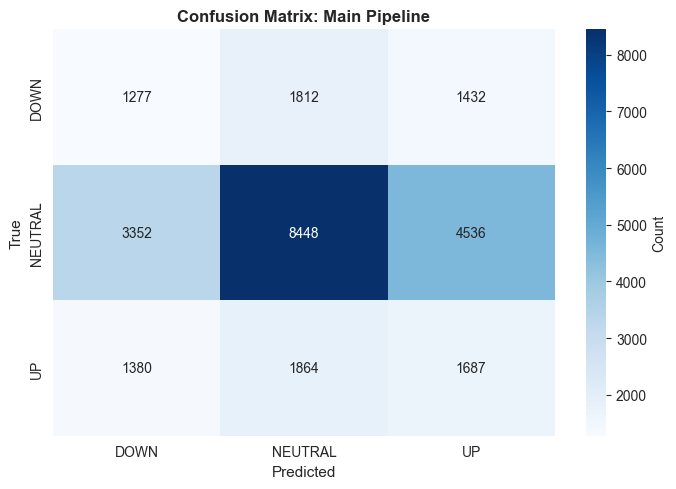

✓ Confusion matrix saved to confusion_matrix.png


In [11]:
cm = confusion_matrix(y_test, y_pred_main, labels=['DOWN', 'NEUTRAL', 'UP'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['DOWN', 'NEUTRAL', 'UP'],
            yticklabels=['DOWN', 'NEUTRAL', 'UP'], ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix: Main Pipeline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Confusion matrix saved to confusion_matrix.png')

## 11. Feature Importance with Names

In [12]:
# Extract feature names
feature_names = []
feature_names.extend([f'ticker_{t}' for t in enc_ticker.get_feature_names_out()])
feature_names.extend([f'title_{t}' for t in vec_title.get_feature_names_out()])
feature_names.extend([f'text_{t}' for t in vec_text.get_feature_names_out()])
feature_names.extend([f'mention_{t}' for t in mlb_mentions.classes_])
feature_names.extend(SENTIMENT_COLS + EMOTION_COLS)

assert len(feature_names) == X_train_full.shape[1], f'Name count mismatch: {len(feature_names)} vs {X_train_full.shape[1]}'

# Get top features by absolute coefficient
coefs = np.abs(clf_final.coef_).mean(axis=0).flatten()
top_idx = np.argsort(-coefs)[:15]

print('Top 15 Most Important Features')
print('='*60)
for rank, idx in enumerate(top_idx, 1):
    fname = feature_names[idx]
    importance = coefs[idx]
    print(f'{rank:2d}. {fname:40s} {importance:.6f}')

Top 15 Most Important Features
 1. text_sept                                4.112628
 2. text_2022                                3.710225
 3. ticker_ticker_CVX                        2.069299
 4. text_feb                                 2.047319
 5. text_2023                                1.894397
 6. text_nov                                 1.829183
 7. mention_CVX                              1.806274
 8. text_jan                                 1.738628
 9. ticker_ticker_BRK                        1.620004
10. ticker_ticker_MRNA                       1.591142
11. text_aug                                 1.569103
12. text_july                                1.469351
13. mention_SQ                               1.311912
14. ticker_ticker_MRK                        1.302771
15. text_september                           1.267399


## 12. Feature Importance Plot

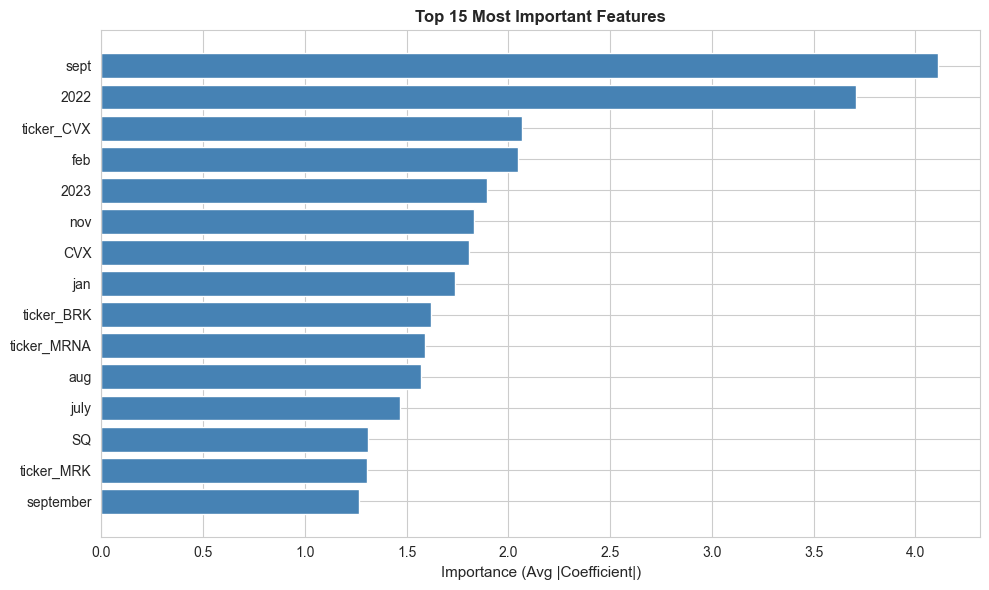

✓ Feature importance plot saved to feature_importance.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(top_idx))
importances = coefs[top_idx]
names_short = [feature_names[i].split('_', 1)[1][:30] for i in top_idx]  # Shorten names
ax.barh(y_pos, importances, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(names_short, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance (Avg |Coefficient|)', fontsize=11)
ax.set_title('Top 15 Most Important Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Feature importance plot saved to feature_importance.png')

## 13. Summary

In [14]:
print('\n' + '='*70)
print('SUMMARY')
print('='*70)
print(f'Target: 3-class stock movement (±{NEUTRAL_BAND*100:.0f}% neutral band)')
print(f'Train/Test: {len(df_train):,} / {len(df_test):,} (temporal split)')
print(f'\nBaselines:')
print(f'  • Majority class: {df['target'].value_counts().index[0]}')
print(f'  • Sentiment-only: F1={f1_sentiment:.4f}')
if finbert_available:
    print(f'  • FinBERT embedding: F1={f1_finbert:.4f}')
print(f'\nMain pipeline:')
print(f'  • Features: Ticker (OHE) + Title (TF-IDF bigrams) + Body (TF-IDF unigrams)')
print(f'  • + Mentions (multi-hot) + Sentiment/emotion (10 features)')
print(f'  • Classifier: LogisticRegression (C={best_C_main}, saga solver, balanced weights)')
print(f'  • Test Macro-F1: {f1_main:.4f}')
print(f'  • Test Accuracy: {acc_main:.4f}')
print(f'\nImprovement vs sentiment baseline: +{improvement:.1f}%')
print(f'\nHyperparameters cached in {CACHE_FILE}. Next run will load them (no grid search).')
print('='*70)


SUMMARY
Target: 3-class stock movement (±2% neutral band)
Train/Test: 60,169 / 25,788 (temporal split)

Baselines:
  • Majority class: NEUTRAL
  • Sentiment-only: F1=0.3293

Main pipeline:
  • Features: Ticker (OHE) + Title (TF-IDF bigrams) + Body (TF-IDF unigrams)
  • + Mentions (multi-hot) + Sentiment/emotion (10 features)
  • Classifier: LogisticRegression (C=1.0, saga solver, balanced weights)
  • Test Macro-F1: 0.3681
  • Test Accuracy: 0.4425

Improvement vs sentiment baseline: +11.8%

Hyperparameters cached in hyperparameters.json. Next run will load them (no grid search).
